In [5]:
# import deconstruct as c

# class InputEvent(c.Struct):
#     W: c.uint32
#     L: c.uint32
#     N: c.uint32
#     value: c.int32

class Task:
    def __init__(self, W, L, N, items, K):
        self.W = W
        self.L = L
        self.N = N # N = len(items)
        self.items = items
        self.K = K # moves per one item


In [4]:
class TaskGenerator:
    def __init__(self):
        raise NotImplementedError

    def Gen(self, n):
        pass

In [1]:
import ctypes
import numpy as np
from numpy.ctypeslib import ndpointer

In [2]:
import subprocess
import ctypes
import _ctypes
import os
import numpy as np
from pathlib import Path

solution_type = {
    "tower": 0,
    "random": 1,
    "greedy-random": 2,
    "lowest-fit": 3
}

lib = 0

from typing import Tuple, Optional

class ErrorInfo(ctypes.Structure):
    _fields_ = [("message", ctypes.c_char_p),
                ("error_code", ctypes.c_int)]

class CppException(Exception):
    """Custom exception for C++ errors"""
    def __init__(self, message, error_code):
        super().__init__(f"C++ Error {error_code}: {message}")
        self.error_code = error_code

def compile_cpp_library():
    # Define paths
    cpp_file = "./3d-packing/main.cpp"
    output_lib = "./libmodule.so"
    
    # Check if source file exists
    if not os.path.exists(cpp_file):
        raise FileNotFoundError(f"C++ source file not found at {cpp_file}")

    # g++ -std=c++20 -shared -fPIC -o ./libmodule.so ./3d-packing/main.cpp 
    # Compile command
    compile_cmd = [
        "g++",
        "-std=c++20",
        "-shared",
        "-fPIC",
        "-o", output_lib,
        cpp_file
    ]
    
    # Execute compilation
    try:
        result = subprocess.run(
            compile_cmd,
            check=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )
        print("Compilation successful!")
        print(result.stdout)
    except subprocess.CalledProcessError as e:
        print("Compilation failed!")
        print("Error message:")
        print(e.stderr)
        raise

def reload_cdll(lib_path):
    """Reloads a ctypes.CDLL library."""
    
    # Ensure the library path is absolute
    lib_path = os.path.abspath(lib_path)

    print(reload_cdll.loaded_libs)
    # Check if the library is currently loaded
    if lib_path in reload_cdll.loaded_libs:
        libcd = reload_cdll.loaded_libs[lib_path]
        
        # Unload the library
        _ctypes.dlclose(libcd._handle)
        del reload_cdll.loaded_libs[lib_path]
        
        
    # Load the library
    libcd = ctypes.CDLL(lib_path)
    reload_cdll.loaded_libs[lib_path] = libcd
    return libcd

reload_cdll.loaded_libs = {}

def prepare_cpp_solutions():
    compile_cpp_library()
    
    lib = reload_cdll('./libmodule.so')

    lib.process_task.argtypes = [
        ctypes.c_int, # n
        ctypes.c_int, # w
        ctypes.c_int, # l
        ctypes.c_int, # k - max_move_count
        ndpointer(ctypes.c_int, flags="C_CONTIGUOUS"), # items [dx0, dy0, dz0, dx1, dy1, dz1, ... ]
        ctypes.c_int, # solution_type
        ctypes.POINTER(ctypes.POINTER(ctypes.c_int)),  # moves [item_id, x, y, z, item_id, x, y, z, ...]
        ctypes.POINTER(ctypes.c_int),                  # move count (single int)
        ndpointer(ctypes.c_int, flags="C_CONTIGUOUS"), # pos [x, y, z, x, y, z, x, y, z, x, y, z]
        ctypes.POINTER(ErrorInfo)
    ]
    lib.process_task.restype = None
    
    lib.free_moves.argtypes = [ctypes.POINTER(ctypes.c_int)]
    lib.free_moves.restype = None

    lib.free_error.argtypes = [ctypes.POINTER(ErrorInfo)]
    lib.free_error.restype = None

    return lib

def get_solution(lib, n, items, w, l, k, solution_type_name):
    pos_array = np.empty((n * 3), dtype=np.int32)
    
    # Prepare output variables
    moves_array = ctypes.POINTER(ctypes.c_int)()
    moves_size = ctypes.c_int()

    error = ErrorInfo()

    try:
        lib.process_task(
            n, w, l, k, items,
            solution_type[solution_type_name],
            ctypes.byref(moves_array), ctypes.byref(moves_size),
            pos_array,
            ctypes.byref(error)
        )

        if error.message:
            raise CppException(error.message.decode('utf-8'), error.error_code)
        # Call the function
        # lib.generate_array(ctypes.byref(out_array), ctypes.byref(out_size))
        
        # Convert to Python list
        moves_result = [moves_array[i] for i in range(moves_size.value)]
        
        # Free memory
        return (moves_result, pos_array)
    except Exception as e:
        print(e)
    finally:
        lib.free_error(ctypes.byref(error))
        lib.free_moves(moves_array)
    return (0, 0)


In [3]:
def calculate_mass_centers(pos, items):
    """
    Calculate mass centers for each rectangle and the overall center
    
    Parameters:
        pos : (N,3) array of [x0,y0,z0] positions
        items : (N,3) array of [dx,dy,dz] dimensions
        
    Returns:
        individual_centers : (N,3) array of individual centers
        overall_center : (3,) array of combined mass center
    """
    # Calculate volumes (proportional to mass)
    volumes = items[:, 0] * items[:, 1] * items[:, 2]
    
    # Calculate individual centers (position + half dimensions)
    individual_centers = pos + items/2
    
    # Calculate overall mass center (weighted average)
    overall_center = np.sum(individual_centers * volumes[:, np.newaxis], axis=0) / np.sum(volumes)
    
    return overall_center


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_3d_rectangles(pos, items, colors=['b'], alpha=0.5, ax=None):
    """
    Plot 3D rectangles given positions and dimensions.
    
    Parameters:
        pos : np.array of shape (N, 3) - [x0, y0, z0] positions
        items : np.array of shape (N, 3) - [dx, dy, dz] dimensions
        color : color of the rectangles
        alpha : transparency (0-1)
        ax : existing 3D axis (creates new if None)
    """
    if ax is None:
        fig = plt.figure(figsize=(5, 5))
        ax = fig.add_subplot(111, projection='3d')
    
    # Convert to numpy arrays if they aren't already
    pos = np.asarray(pos)
    items = np.asarray(items)
    
    # Verify shapes
    if pos.shape[1] != 3 or items.shape[1] != 3:
        raise ValueError("Input arrays must have shape (N, 3)")
    if len(pos) != len(items):
        raise ValueError("pos and items must have same length")

    i = -1
    for (x0, y0, z0), (dx, dy, dz) in zip(pos, items):
        i += 1
        # Define the 8 vertices of the rectangular prism
        vertices = [
            [x0, y0, z0],
            [x0+dx, y0, z0],
            [x0+dx, y0+dy, z0],
            [x0, y0+dy, z0],
            [x0, y0, z0+dz],
            [x0+dx, y0, z0+dz],
            [x0+dx, y0+dy, z0+dz],
            [x0, y0+dy, z0+dz]
        ]
        
        # Define the 6 faces using the vertices
        faces = [
            [vertices[0], vertices[1], vertices[2], vertices[3]],  # bottom
            [vertices[4], vertices[5], vertices[6], vertices[7]],  # top
            [vertices[0], vertices[1], vertices[5], vertices[4]],  # front
            [vertices[2], vertices[3], vertices[7], vertices[6]],  # back
            [vertices[1], vertices[2], vertices[6], vertices[5]],  # right
            [vertices[0], vertices[3], vertices[7], vertices[4]]   # left
        ]
        
        # Plot each face
        ax.add_collection3d(Poly3DCollection(
            faces, 
            facecolors=colors[i % len(colors)], 
            linewidths=1, 
            edgecolors='k', 
            alpha=alpha
        ))
    
    # Auto-scale the axes
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    # ax.autoscale_view()
    
    return ax

def show_solution(items, pos, solution_type_name, colors=['b'], alpha=0.5):
    ax = plot_3d_rectangles(pos, items, colors=colors, alpha=alpha)
    # for i in range(1, len(items)):
    #     color = colors[i % len(colors)]
    #     plot_3d_rectangles(pos[i:i + 1], items[i:i + 1], colors=colors, ax=ax)  # Second in green
    # plot_3d_rectangles(pos[2:], items[2:], color='b', ax=ax)  # Third in blue

    # ax.set_xlim([0, w])
    # ax.set_ylim([0, l])
    # Set equal aspect ratio
    ax.set_box_aspect([1, 1, 1])  # This is the key line!
    
    # Auto-scale while maintaining aspect
    all_points = np.vstack([pos, pos + items])
    min_vals = all_points.min(axis=0)
    max_vals = all_points.max(axis=0)

    min_x = min_vals.min()
    max_x = max_vals.max()
    
    ax.set_xlim(min_x, max_x)
    ax.set_ylim(min_x, max_x)
    ax.set_zlim(min_x, max_x)

    # Set ticks at zero
    # ax.set_xticks([0])
    # ax.set_yticks([0])
    # ax.set_zticks([0])
    # ax.set_box_aspect([1,1,1])
    ax.view_init(elev=20, azim=35)

    mass_center = calculate_mass_centers(pos, items)
    
    plt.title(solution_type_name + ": h=" + str(max_vals[2]) + " mass_center=" + str(round(mass_center[2], 2)))
    plt.tight_layout()
    plt.show()


In [27]:
def plot_2d_rectangles(pos, items, colors=['b'], alpha=0.5, ax=None):
    """
    Plot rectangles in 2D
    
    Parameters:
        pos : np.array of shape (N, 3) - [x0, y0, z0] positions
        items : np.array of shape (N, 3) - [dx, dy, dz] dimensions
        color : color of the rectangles
        alpha : transparency (0-1)
        ax : existing axis (creates new if None)
        two_d : if True, draws 2D projection (dy becomes 1)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    pos = np.asarray(pos)
    items = np.asarray(items)
    
    if pos.shape[1] != 3 or items.shape[1] != 3:
        raise ValueError("Input arrays must have shape (N, 3)")
    if len(pos) != len(items):
        raise ValueError("pos and items must have same length")
    
    # For 2D projection (X-Z plane)
    i = -1
    for (x0, _, z0), (dx, _, dz) in zip(pos, items):
        i += 1
        rect = plt.Rectangle((x0, z0), dx, dz, 
                           facecolor=colors[i % len(colors)], 
                           edgecolor='k',
                           alpha=alpha)
        ax.add_patch(rect)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Z')
    ax.set_title('2D Projection (X-Z plane)')
    ax.grid(True)
    ax.set_aspect('equal')
    
    # Auto-scale the axes
    all_points = np.vstack([pos, pos + items])
    min_vals = all_points.min(axis=0)
    max_vals = all_points.max(axis=0)
    ranges = max_vals - min_vals
    padding = 0.1 * ranges
    
    ax.set_xlim(min_vals[0]-padding[0], max_vals[0]+padding[0])
    ax.set_ylim(min_vals[2]-padding[2], max_vals[2]+padding[2])
    
    return ax

def show_solution_2d(items, pos, solution_type_name, colors, alpha=0.5, ax=None):
    ax = plot_2d_rectangles(pos, items, colors=colors, alpha=alpha, ax=ax)
    # ax.set_box_aspect([1, 1, 1])  # This is the key line!
    
    all_points = np.vstack([pos, pos + items])
    min_vals = all_points.min(axis=0)
    max_vals = all_points.max(axis=0)

    min_x = min_vals.min()
    max_x = max_vals.max()
    ranges = max_x - min_x
    
    ax.set_xlim(min_x - ranges * 0.1, max_x + ranges * 0.1)
    ax.set_ylim(min_x - ranges * 0.1, max_x + ranges * 0.1)

    # plt.title(solution_type_name)
    mass_center = calculate_mass_centers(pos, items)
    plt.title(solution_type_name + ": h=" + str(max_vals[2]) + " mass_center=" + str(round(mass_center[2], 2)))
    plt.tight_layout()
    plt.show()

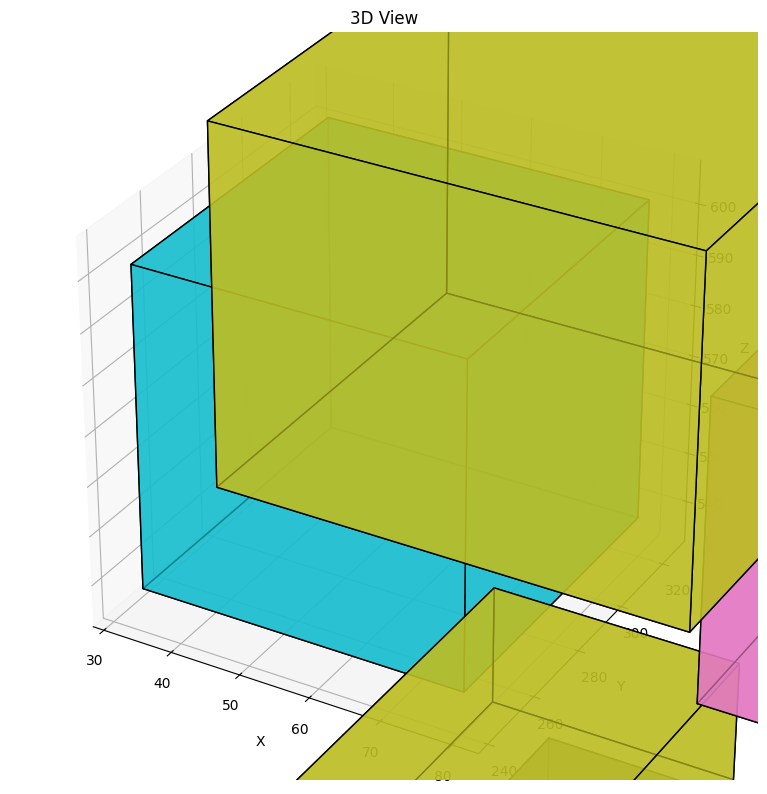

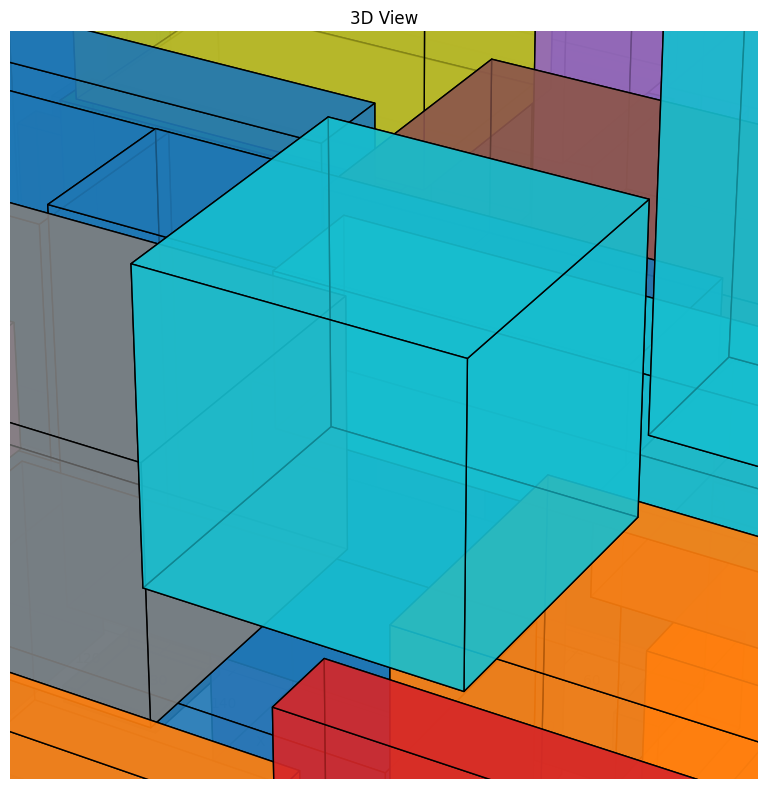

In [33]:
# for solution in solutions:
#     items, pos, solution_type_name = solution
#     items = items.reshape((-1, 3))
#     pos = pos.reshape((-1, 3))
    
#     colors = plt.cm.tab10(np.linspace(0, 1, len(pos)))
    
#     # Plot 3D version
#     fig1 = plt.figure(figsize=(10, 8))
#     ax1 = fig1.add_subplot(111, projection='3d')
#     for i in range(len(pos)):
#         plot_rectangles(pos[i:i+1], items[i:i+1], 
#                        color=colors[i], 
#                        alpha=0.7, 
#                        ax=ax1)
#     plt.title("3D View")
    
#     plt.tight_layout()
#     plt.show()


In [37]:
# ! g++ -std=c++20 -shared -fPIC -o libmodule.so ./3d-packing/main.cpp

In [20]:
n = 200
w = 500
l = 500
k = 0

xmin = 4
xmax = 100
items = np.random.randint(xmin, xmax, 3 * n, dtype=np.int32)
# items = np.array([1, 2, 3, 4, 5, 6], dtype=np.int32)

print(items)

solutions = []

solution_type_list = [
    "random",
    "greedy-random",
    "lowest-fit"
]

lib_solution = prepare_cpp_solutions()

for solution_type_name in solution_type_list:
    try:
        moves, pos = get_solution(lib_solution, n, items, w, l, k, solution_type_name)
        solutions.append((items, pos, solution_type_name))
    except Exception as e:
        print(e)

# moves, pos = get_solution(n, items, w, l, k, "random")
# print("Input:", items)
# print("Output:", moves, pos)


[ 5  4 44 72 57 43 56 44 64 45 12 58 56 17 25 94 19 48 45 79 20 76 67 37
 31 11 13 94 52 96 93 45 62 34 22  9 57  4 98  5 29 71 69 54 47 27 18 63
 37 97 56 38 34 33 62 42 65 26 74 57 29 34 81 74 39 38 86 12 90 88 85 22
 79 33 68 28  5 49 48 78  4 40 94 17 81 53 85 25 58 18 68 24 81 82 72 97
 26 71  7 74 51 14 95 17 78 15 48 81 91 73 32 29 18 21 30 37 39 90 10 21
 28 15 90 36  9 10 33 47 50  6 73 24 66 94 46 99 27 36 99 40 46 34 37 30
 63 20 87 70 87 14  8 66 79 62 88 89 55 67 43 95  7 67 85 55  9 79 63 65
 88 87 46 57 37 37 83 16 74 96 84 88 87 15 60 11 84 30 78 84  9 58 62  8
 81 49 98 81 99 83 47 33 66 39 48 25 24 26 76 23 29  5 31 17 50 10 26 25
 71 67 16 29 46 28 39 73 13 57 95 45 55 87 41 99 61 41 86 39 33 44 17 95
 45 55 56 74 90 85 85 70 93 93 89 47 12 37 99  7 48 31 32 91 18 80  7 20
 13 94 67 80 43 54 56 78 51 70 95 16  4 89 76 77 48 47 85 25 35 50 34 73
 36 71 79 78 61 65 61 82 32 15 39 93 59 57 20 68 84 59 59  8 63 43 14  9
 86 43 88 64 10 35 85 60 22 12 17 60 50 76 86 18  8

44 0
43 0
64 0
58 0
25 0
48 0
20 25
37 0
13 0
96 45
62 37
9 64
98 0
71 0
47 0
63 0
56 141
33 47
65 0
57 0
81 43
38 0
90 0
22 99
68 45
49 0
4 73
17 121
85 65
18 141
81 150
97 57
7 99
14 58
78 113
81 0
32 138
21 0
39 98
21 121
90 0
10 142
50 137
24 64
46 90
36 191
46 25
30 197
87 187
14 71
79 0
89 152
43 79
67 136
9 241
65 72
46 85
37 77
74 154
88 228
60 227
30 0
9 250
8 124
98 287
83 274
66 316
25 0
76 250
5 131
50 0
25 357
16 259
28 136
13 122
45 131
41 164
41 227
33 326
95 47
56 382
85 357
93 250
47 326
99 0
31 0
18 141
20 442
67 373
54 316
51 373
16 373
76 287
47 268
35 440
73 438
79 389
65 424
32 511
93 77
20 389
59 274
63 489
9 141
88 50
35 373
22 268
60 359
86 543
18 25
31 440
7 315
55 489
81 475
83 315
38 552
73 590
75 138
84 0
94 468
23 663
67 562
11 543
88 629
45 290
46 629
9 471
21 590
15 717
9 150
26 732
71 462
9 170
42 686
53 176
54 77
4 398
56 629
84 385
16 758
58 408
44 675
25 359
65 333
42 685
5 442
12 402
72 727
36 229
34 229
11 675
21 213
29 159
35 758
54 480
87 408
93 

HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE

16 39
76 0
47 9
35 22
73 17
79 4
65 32
32 46
93 0
20 33
59 46
63 0
9 0
88 46
35 0
22 54
60 0
86 43
18 0
31 37
7 18
55 0
81 45
83 32
38 46
73 56
75 55
84 0
94 65
23 37
67 68
11 47
88 45
45 0
46 65
9 56
21 45
15 65
9 53
26 58
71 46
9 62
42 60
53 63
54 25
4 71
56 72
84 9
16 76
58 17
44 57
25 0
65 68
42 76
5 64
12 32
72 68
36 69
34 0
11 44
21 0
29 46
35 78
54 83
87 0
93 0
76 55
49 75
49 66
62 62
51 75
49 78
83 88
67 75
22 71
23 76
58 0
80 80
49 67
42 79
69 81
31 84
63 4
25 88
13 89
7 81
83 83
45 45
18 38
5 20
77 92
40 84
41 85
35 0
84 90
27 56
28 97
6 83
43 88
52 97
84 90
61 98
33 96


HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE!
HERE

27 80
37 74
81 102
47 97
62 81
8 25
44 0
43 0
64 0
58 0
25 0
48 0
20 0
37 0
13 0
96 0
62 0
9 0
98 0
71 0
47 0
63 0
56 0
33 0
65 0
57 0
81 0
38 0
90 0
22 0
68 0
49 0
4 0
17 0
85 0
18 0
81 0
97 0
7 0
14 0
78 0
81 0
32 0
21 0
39 0
21 0
90 0
10 0
50 0
24 0
46 0
36 0
46 0
30 0
87 0
14 0
79 0
89 0
43 0
67 0
9 0
65 0
46 0
37 0
74 0
88 0
60 0
30 0
9 0
8 0
98 0
83 0
66 0
25 0
76 0
5 0
50 0
25 0
16 0
28 0
13 0
45 0
41 0
41 13
33 0
95 0
56 0
85 28
93 21
47 41
99 0
31 0
18 0
20 0
67 0
54 18
51 14
16 39
76 0
47 9
35 22
73 17
79 4
65 32
32 46
93 0
20 33
59 46
63 0
9 0
88 46
35 0
22 54
60 0
86 43
18 0
31 37
7 18
55 0
81 45
83 32
38 46
73 56
75 55
84 0
94 65
23 37
67 68
11 47
88 45
45 0
46 65
9 56
21 45
15 65
9 53
26 58
71 46
9 62
42 60
53 63
54 25
4 71
56 72
84 9
16 76
58 17
44 57
25 0
65 68
42 76
5 64
12 32
72 68
36 69
34 0
11 44
21 0
29 46
35 78
54 83
87 0
93 0
76 55
49 75
49 66
62 62
51 75
49 78
83 88
67 75
22 71
23 76
58 0
80 80
49 67
42 79
69 81
31 84
63 4
25 88
13 89
7 81
83 83
45 45
18 38
5 20

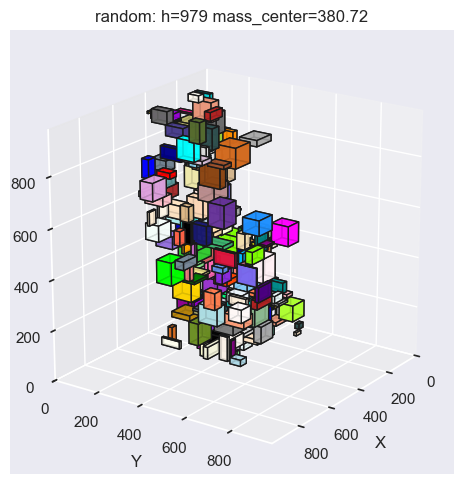

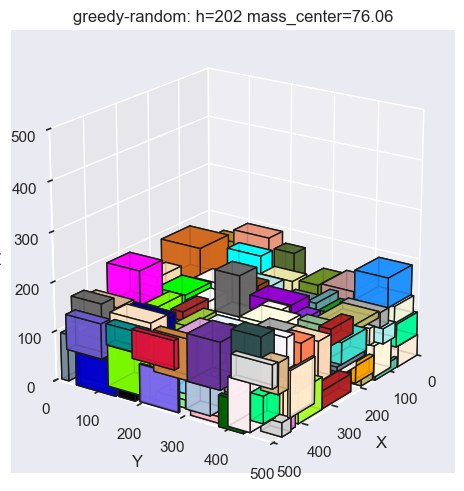

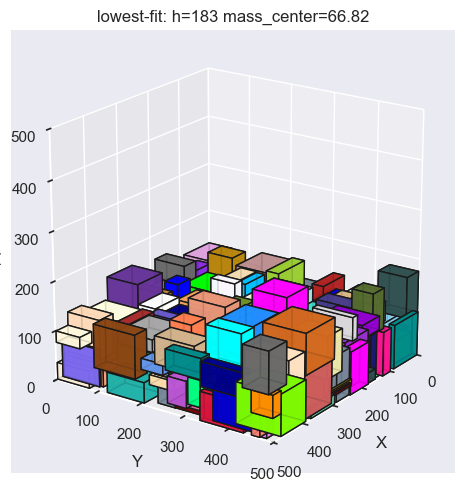

In [21]:
import seaborn as sns

# Set seaborn style first
sns.set_theme(style="darkgrid")  # or "darkgrid", "white", "dark"

from matplotlib import colors as mcolors

# Get list of named CSS colors
colors = list(mcolors.CSS4_COLORS.values())

for solution in solutions:
    items, pos, solution_type_name = solution
    show_solution(items.reshape((-1, 3)), pos.reshape((-1, 3)), solution_type_name, colors=colors, alpha=0.85)


In [25]:
# for 2D:
n = 100
w = 1000
l = 1
k = 0

xmin = 4
xmax = 100
items = np.random.randint(xmin, xmax, 3 * n, dtype=np.int32)
for i in range(n):
    items[3 * i + 1] = 1
# items = np.array([1, 2, 3, 4, 5, 6], dtype=np.int32)

solutions_2d = []

solution_type_list = [
    "random",
    "greedy-random",
    "lowest-fit"
]

lib_solution = prepare_cpp_solutions()

for solution_type_name in solution_type_list:
    moves, pos = get_solution(lib_solution, n, items, w, l, k, solution_type_name)
    solutions_2d.append((items, pos, solution_type_name))


Compilation successful!

{'/Users/belkovanya/coding/github/scientific-work/strip-packing/libmodule.so': <CDLL '/Users/belkovanya/coding/github/scientific-work/strip-packing/libmodule.so', handle 8b65a7d0 at 0x16a399b50>}


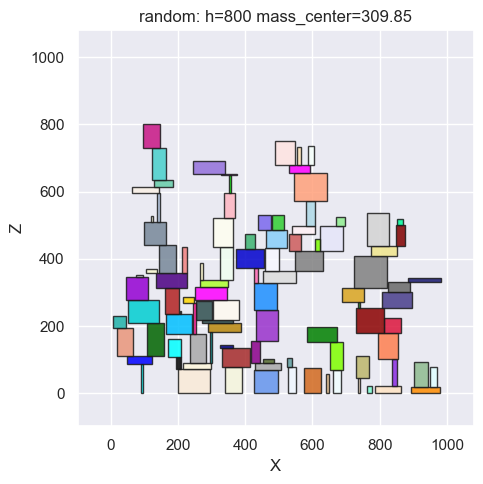

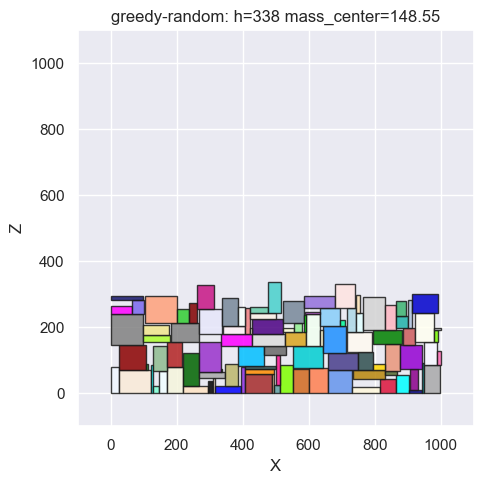

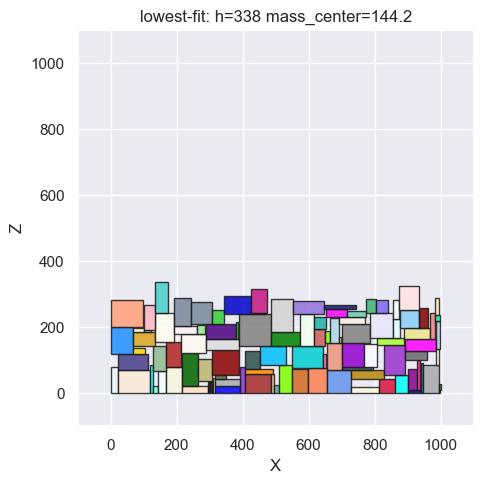

In [28]:
import seaborn as sns

# Set seaborn style first
sns.set_theme(style="darkgrid")  # or "darkgrid", "white", "dark"

from matplotlib import colors as mcolors

# Get list of named CSS colors
colors = list(mcolors.CSS4_COLORS.values())

for solution in solutions_2d:
    items, pos, solution_type_name = solution
    fig, ax = plt.subplots(figsize=(5, 5))
    show_solution_2d(items.reshape((-1, 3)), pos.reshape((-1, 3)), solution_type_name, colors=colors, alpha=0.85, ax=ax)
